# **Getting started**: lorentzian basis super-resolution

Measured signals may get corrupted by various factors, such as measurement-induced uncertainties, physics-based resolution limitations and noise corruption through intrinsic and external sources. The package **cssr** (compressive sensing-based super-resolver) is intended to tackle physics-based resolution limitations and noise simultaneously. Specifically, the package intends to recover signals that admit a sparse representation which have been low-pass filtered and are subject to noise corruption. 

## Preliminaries:

We start by importing the package **cssr**:

In [1]:
import cssr

Next, let us import the needed packages for the plotting specifications and to construct our trial signal:

In [2]:
import scipy
import random
import numpy as np
import matplotlib.pyplot as plt

Let us also specify the font sizes for the plots that we will construct sortly after:

In [3]:
font1 = 17
font2 = 13

For convenience, we disable the warnings that appear during the plotting porcedure:

In [4]:
import warnings
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

## Setting up a trial signal:

We are now ready to set up the trail signal, set up in two steps. In step 1, we construct the sparse representation of the signal, followed by applying a convolution on the sparse representation with a Lorentzian distribution (also known as a Cauchy distribution). The resulting array is called the original signal. In step 2, a lowpass filter is applied on the original signal, followed by additional signal corruption through a noise term (representing a signal as measured in a real world scenario).

Before we do this though, let us first set the random seeds to specific values for convenience:

In [5]:
np.random.seed(9)
random.seed(9)

### Step 1:

#### **Sparse representation**:

We choose to set up a signal with 8 peaks, i.e., a 8-sparse signal, in a time interval of 20 seconds and a time resolution of 0.1 seconds:

In [6]:
n_peaks = 8
x = np.arange(0, 20, 0.1)
dim = x.shape[0]

Next, the amplitudes and the locations of these peaks are randomly assigned. In particular, we randomly choose amplitudes within an interval between -1 and 1, and we randomly choose the location of the peaks within 1/6 and 5/6 of the considered time interval of the signal:

In [7]:
amps = 2 * np.random.random(size=(dim,1)) - 1
peaks = random.sample(range(dim//6, 5*dim//6), n_peaks)

Finally, the constructed objects are used to set up the sparse trial signal $y_{\text{sparse}}(t)$:

In [8]:
y_sparse = np.zeros((dim, 1))
y_sparse[peaks] = amps[peaks]

It is convenient to already extract the minimum and maximum signal magnitude for plotting purposes:

In [9]:
amp_max = max(y_sparse)*(1 + 0.05)
amp_min = min(y_sparse)*(1 + 0.05)

#### **Ground truth**:

To construct the original signal $y_{\text{original}}(t)$, we choose to convolve its sparse representation with a Lorentzian distribution with a half-width at half-maximum $\sigma$ = 0.2. This is achieved by first constructing a corresponding frame (known as a dictionary in the compressive sensing literature):

In [10]:
sigma = 0.2
a0 = cssr.Frames(x).cauchy(sigma)

followed by a convolution with the sparse representation of the signal:

In [11]:
y_original = a0.dot(y_sparse)

#### Visualization:

Let us take a quick look at the constructedd signal:

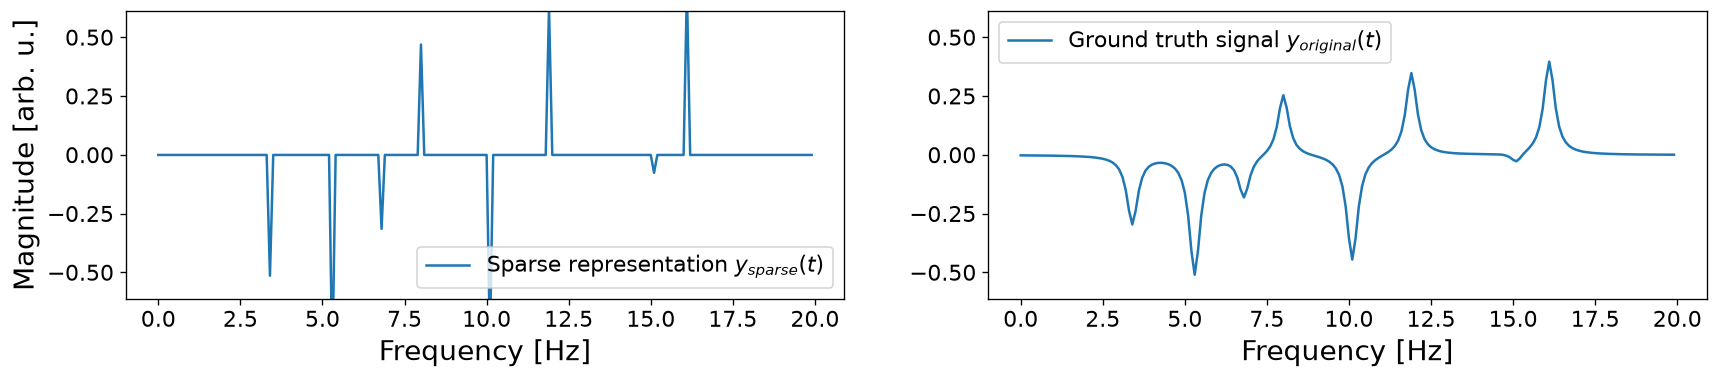

In [12]:
ylim_min = min(y_original.real)*1.2
ylim_max = max(abs(y_original))*1.2

fig1, axs1 = plt.subplots(1, 2, figsize=(17,17), dpi=120)

axs1[0].plot(x, y_sparse, label="Sparse representation $y_{sparse}(t)$")
axs1[1].plot(x, y_original, label="Ground truth signal $y_{original}(t)$")

axs1[0].set_ylabel("Magnitude [arb. u.]", fontsize=font1)
axs1[0].set_xlabel("Frequency [Hz]", fontsize=font1)
axs1[1].set_xlabel("Frequency [Hz]", fontsize=font1)

axs1[0].legend(fontsize=font2)
axs1[1].legend(fontsize=font2)

axs1[0].set_ylim([ylim_min, ylim_max])
axs1[1].set_ylim([ylim_min, ylim_max])

axs1[0].set_box_aspect(aspect=0.4)
axs1[1].set_box_aspect(aspect=0.4)

axs1[0].tick_params(axis='both', which='major', labelsize=font2)
axs1[1].tick_params(axis='both', which='major', labelsize=font2)

plt.show()

### Step 2:

#### **Systemic corruption**:

We can account for system-imposed limitations on the original signal by applying a low-pass filter (giving us the signal $y_{\text{lp}}(t)$) and adding a noise term (giving us the signal $y(t)$). In particular, we choose an ideal low-pass filter that eliminates all frequency beyond a critical value **cutoff**=0.6, denoted the heaviside_lowpass_filter in the **cssr** package. Let us start with the low-pass filter (a linear operator): 

In [13]:
cutoff = 0.6
y_lp = cssr.Filters(y_original, x, cutoff=cutoff, sense_mat=False).heaviside_lowpass_filter()

Next, we add noise to the signal:

In [14]:
noise_level = np.sqrt(0.001)
noise  = np.random.randn(len(x))*noise_level
y = y_lp + noise

For convenience, let quantify the signal-to-noise ration (SNR) in decibel:

In [15]:
if noise_level:
    print("SNR:", 10*np.log10(np.linalg.norm(y)/np.linalg.norm(noise)), "dB")
else:
    print("SNR:", np.inf, "dB")

SNR: 5.335636339857657 dB


#### Visualization:

Let us visualize the signal together with their representations in the frequency space ($y^{\text{fft}}_{\text{original}}(\omega)$, $y^{\text{fft}}_{\text{lp}}(\omega)$, $y^{\text{fft}}(\omega)$), which we generate as follows:

In [16]:
x_fft = scipy.fft.fftshift(scipy.fft.fftfreq(x.shape[0], d=abs(x[0] - x[1])))
y_fft_original = scipy.fft.fftshift(scipy.fft.fft(y_original, axis=0))
y_fft_lp = scipy.fft.fftshift(scipy.fft.fft(y_lp, axis=0))
y_fft = scipy.fft.fftshift(scipy.fft.fft(y, axis=0))

Therefore:

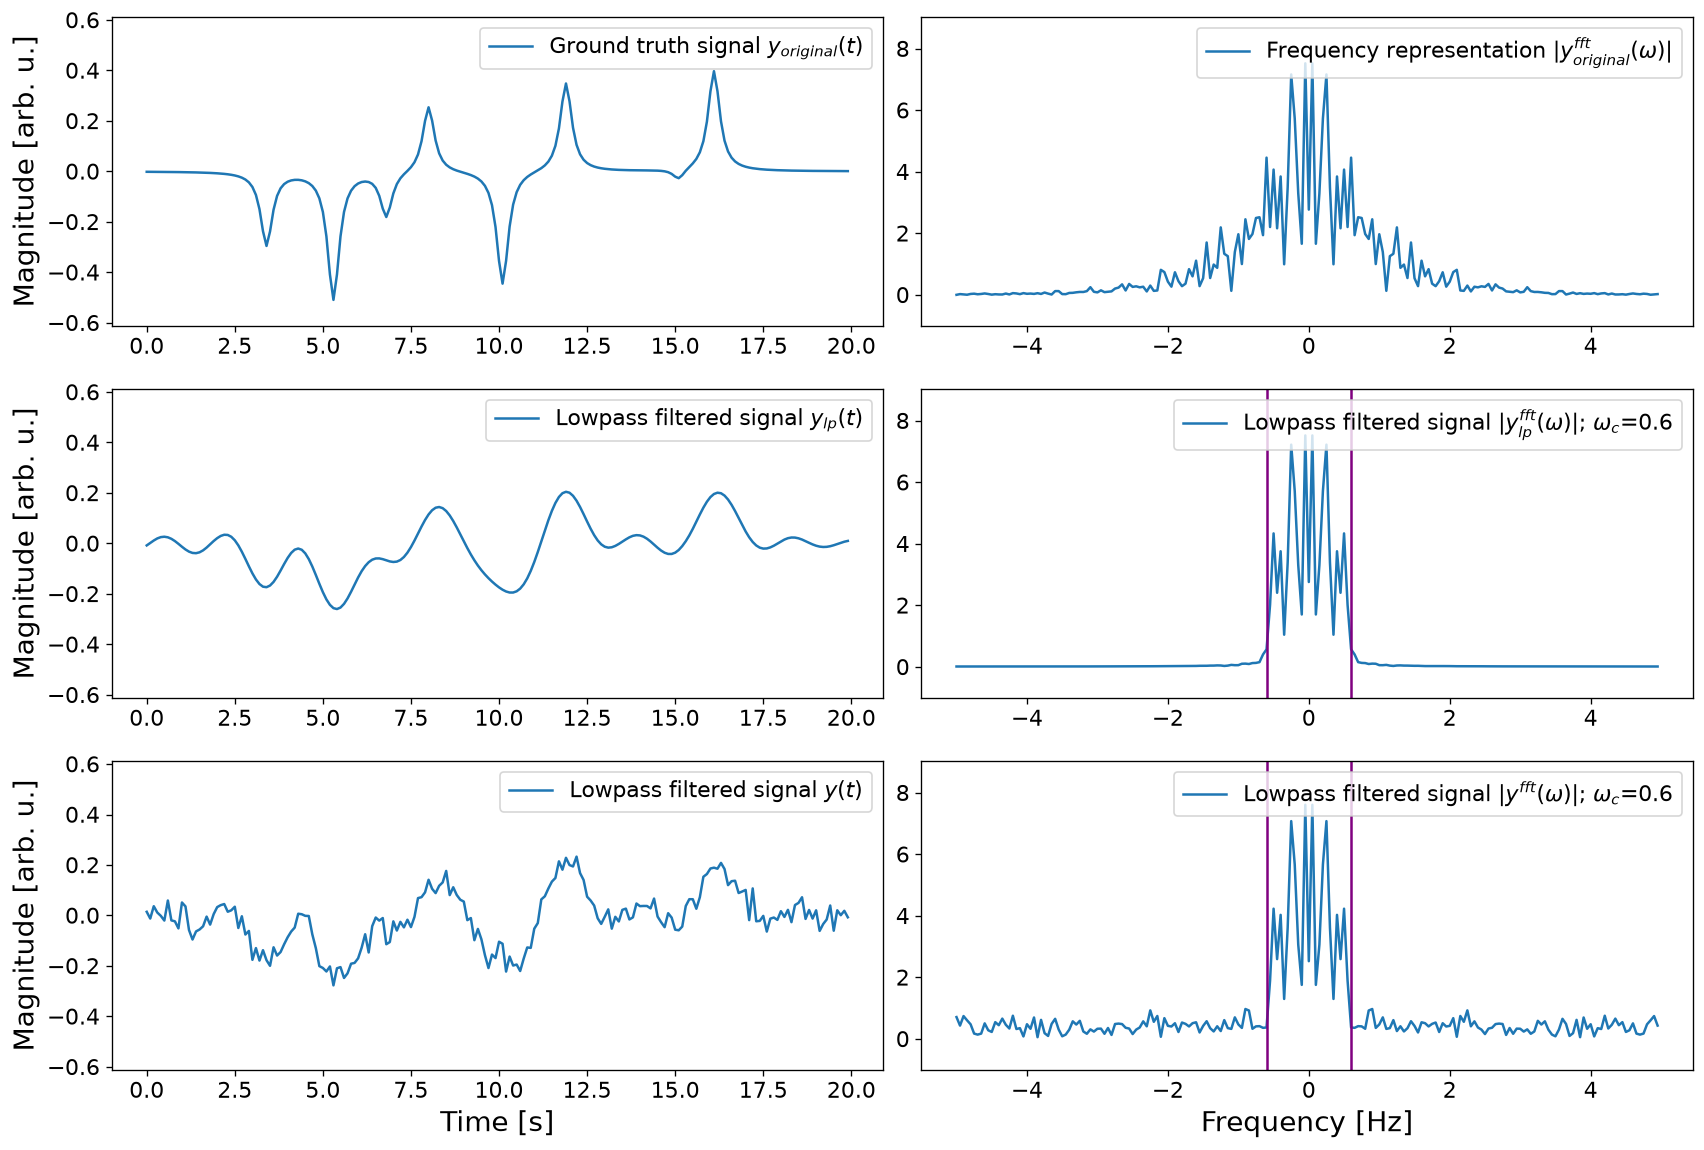

In [17]:
y_fft_lim_max  = max(abs(y_fft_lp))*1.2

fig2, axs2 = plt.subplots(3, 2, figsize=(17, 17), dpi=120)

axs2[0,0].plot(x, y_original, label="Ground truth signal $y_{original}(t)$")
axs2[0,1].plot(x_fft, abs(y_fft_original), label="Frequency representation $|y^{{fft}}_{{original}}(\omega)|$")

axs2[1,0].plot(x, y_lp, label="Lowpass filtered signal $y_{lp}(t)$")
axs2[1,1].plot(x_fft, abs(y_fft_lp), label=f"Lowpass filtered signal $|y^{{fft}}_{{lp}}(\omega)|$; $\omega_c$={cutoff}")

axs2[2,0].plot(x, y, label="Lowpass filtered signal $y(t)$")
axs2[2,1].plot(x_fft, abs(y_fft), label=f"Lowpass filtered signal $|y^{{fft}}(\omega)|$; $\omega_c$={cutoff}")

axs2[0,0].set_ylabel("Magnitude [arb. u.]", fontsize=font1)
axs2[0,0].legend(fontsize=font2)
axs2[0,1].legend(fontsize=font2)

axs2[1,0].set_ylabel("Magnitude [arb. u.]", fontsize=font1)
axs2[1,0].legend(fontsize=font2)
axs2[1,1].legend(fontsize=font2)

axs2[2,0].set_xlabel("Time [s]", fontsize=font1)
axs2[2,1].set_xlabel("Frequency [Hz]", fontsize=font1)
axs2[2,0].set_ylabel("Magnitude [arb. u.]", fontsize=font1)
axs2[2,0].legend(fontsize=font2)
axs2[2,1].legend(fontsize=font2)

axs2[1,1].vlines(x = [-cutoff, cutoff], ymin = -1, ymax = y_fft_lim_max ,
    colors = 'purple', linestyles="solid")
axs2[2,1].vlines(x = [-cutoff, cutoff], ymin = -1, ymax = y_fft_lim_max ,
    colors = 'purple', linestyles="solid")

axs2[0,1].set_ylim([-1, y_fft_lim_max ])
axs2[1,1].set_ylim([-1, y_fft_lim_max ])
axs2[2,1].set_ylim([-1, y_fft_lim_max ])
axs2[0,0].set_ylim([ylim_min, ylim_max])
axs2[1,0].set_ylim([ylim_min, ylim_max])
axs2[2,0].set_ylim([ylim_min, ylim_max])

for ax in axs2.flat:
    ax.set_box_aspect(aspect=0.4)
    ax.tick_params(axis='both', which='major', labelsize=font2)
    
fig2.subplots_adjust(hspace=-0.55, wspace=0.05)

plt.show()

## Sparse basis, low-pass filters and measurement matrices:

We are now ready to set up the central objects to reconstruct signals. It is instructive to gather the needed frame and filter once more, since one would usually start a realistic reconstruction on actual data at the current point:

In [18]:
a0 = cssr.Frames(x).cauchy(sigma)
a_tr = cssr.Filters(a0, x, cutoff=cutoff).heaviside_lowpass_filter()

The compressive sensing based approach is particularly interesting since the needed measurement matrix for the reconstruction can have considerably fewer row vectors then column vectors. Let us set the number of rows to

In [19]:
number_rows = 25

Next, we can now make full use of the compressive sensing based methodology and construct an appropriate measurement matrix. We choose a so-called binary block matrix. This matrix is one of the simplest measurement matrices constructed by inserting blocks of **1s** in a staircase fashion into the diagonal entries of a zero matrix:

In [20]:
ar = cssr.MeasurementMatrices(number_rows, a_tr).binary_block()

Note, matrices with binary entries, such as binary block matrices, can in principle directly be implemented into physical measurement schemes.

## **Super-resolution**:

We are finally ready to perform the compressive sensing-based super-resolution. It is instructive to reconstruct the low-pass filtered signals with and without noise:

### Reconstructing $y_\text{original}(t)$ from $y_\text{lp}(t)$:

To reconstruct the noiseless signal we apply one of the algorithms implemented in the **cssr** package that solve our convex problem. In particular, we choose a hybrid algorithm called MPL assisted non-local hard thresholding, which uses the **matching pursuit** and **basis pursuit denoising** for the reconstruction. The corresponding function is called nlht_lasso, and the reconstruction is performed as follows:

In [21]:
y_lp_reconstructed, y_lp_sparse_hat  = cssr.Superresolvers(a0, a_tr, ar).nlht_lasso(y_lp)

The **cssr** package returns both the reconstructed signal and its reconstructed sparse representation.

#### Visualization:

We are interested in both the reconstructed signal and its frequency space representation. Thus:

In [22]:
y_fft_lp_hat = scipy.fft.fftshift(scipy.fft.fft(y_lp_reconstructed, axis=0))

We can visualize and compare the reconstructed and the original signal as follows:

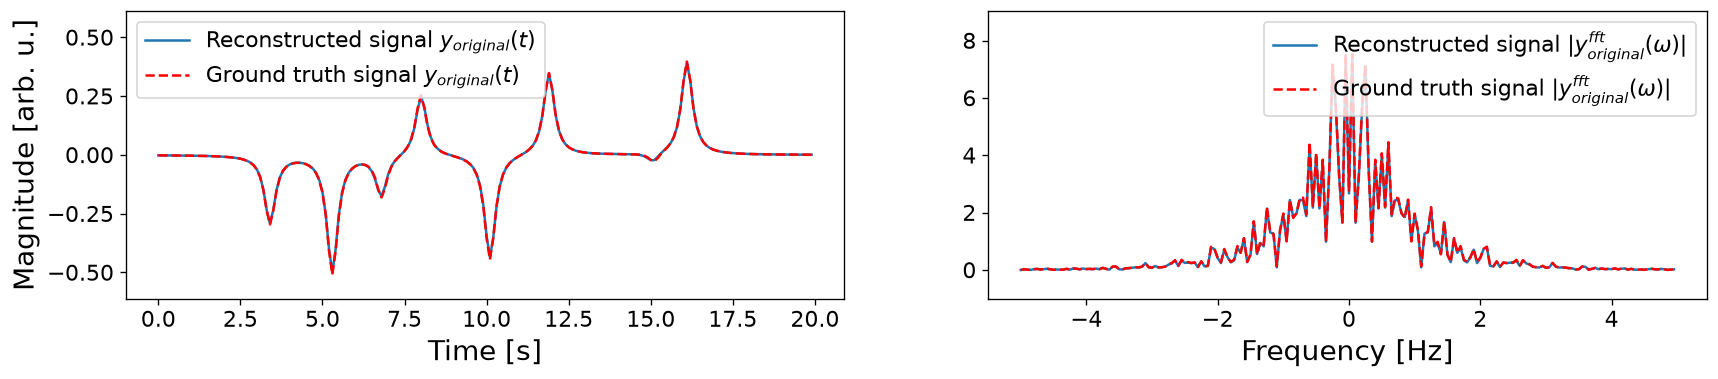

In [23]:
fig3, axs3 = plt.subplots(1, 2, figsize=(17, 9), dpi=120)

axs3[0].plot(x, y_lp_reconstructed, label="Reconstructed signal $y_{original}(t)$")
axs3[0].plot(x, y_original, "--", color="r", label="Ground truth signal $y_{original}(t)$")

axs3[1].plot(x_fft, abs(y_fft_lp_hat), label="Reconstructed signal |$y^{fft}_{original}(\omega)$|")
axs3[1].plot(x_fft, abs(y_fft_original),"--", color="r", label="Ground truth signal |$y^{fft}_{original}(\omega)$|")

axs3[0].set_xlabel("Time [s]", fontsize=font1)
axs3[0].set_ylabel("Magnitude [arb. u.]", fontsize=font1)
axs3[1].set_xlabel("Frequency [Hz]", fontsize=font1)

axs3[0].legend(fontsize=font2)
axs3[1].legend(fontsize=font2)

axs3[0].set_ylim([ylim_min, ylim_max])
axs3[1].set_ylim([-1, y_fft_lim_max ])

axs3[0].set_box_aspect(aspect=0.4)
axs3[1].set_box_aspect(aspect=0.4)

axs3[0].tick_params(axis='both', which='major', labelsize=font2)
axs3[1].tick_params(axis='both', which='major', labelsize=font2)

plt.show()

### Reconstructing $y_\text{original}(t)$ from $y(t)$:

The addition of noise in the corrupted signal, adds another layer of difficulty. In particular, the algorithm may not be able to resolve all sparse features once the noise level significantly overshadows the contained information. To account for the noise magnitude in the signal, we need to specify an optional argument in the solver $\lambda$:

In [24]:
if noise_level:
    noise_magnitude = np.linalg.norm(noise)**2
else:
    noise_magnitude = None
y_reconstructed, y_sparse_hat  = cssr.Superresolvers(a0, a_tr, ar).nlht_lasso(y, lam=noise_magnitude)

We have intentionally written a conditional statement for the noise magnitude determination, intended to give room for experimentation with other noise values. ( In particular, **cssr** has a default noise magnitude for lam=None for noiseless signals that mitigates instabilities. )

#### Visualization:

Once again, let us construct the frequency representation of the reconstructed signal:

In [25]:
y_fft_hat = scipy.fft.fftshift(scipy.fft.fft(y_reconstructed, axis=0))

As before, the result can be visualized as follows:

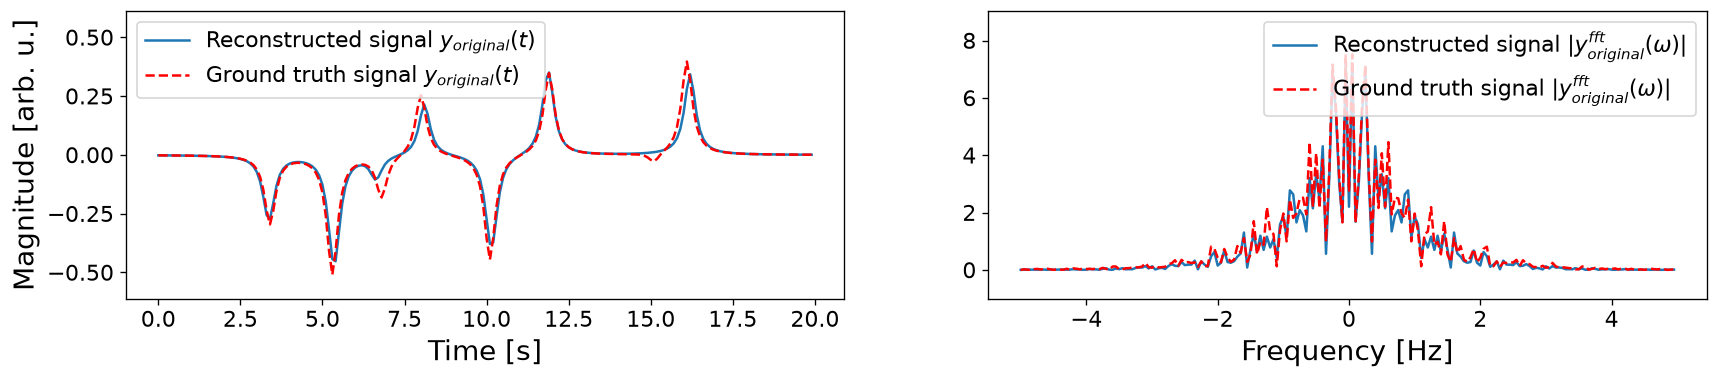

In [26]:
fig4, axs4 = plt.subplots(1, 2, figsize=(17, 9), dpi=120)

axs4[0].plot(x, y_reconstructed, label="Reconstructed signal $y_{original}(t)$")
axs4[0].plot(x, y_original, "--", color="r", label="Ground truth signal $y_{original}(t)$")

axs4[1].plot(x_fft, abs(y_fft_hat), label="Reconstructed signal |$y^{fft}_{original}(\omega)$|")
axs4[1].plot(x_fft, abs(y_fft_original),"--", color="r", label="Ground truth signal |$y^{fft}_{original}(\omega)$|")

axs4[0].set_xlabel("Time [s]", fontsize=font1)
axs4[0].set_ylabel("Magnitude [arb. u.]", fontsize=font1)
axs4[1].set_xlabel("Frequency [Hz]", fontsize=font1)

axs4[0].legend(fontsize=font2)
axs4[1].legend(fontsize=font2)

axs4[0].set_ylim([ylim_min, ylim_max])
axs4[1].set_ylim([-1, y_fft_lim_max ])

axs4[0].set_box_aspect(aspect=0.4)
axs4[1].set_box_aspect(aspect=0.4)

axs4[0].tick_params(axis='both', which='major', labelsize=font2)
axs4[1].tick_params(axis='both', which='major', labelsize=font2)

plt.show()

## Summary, conclusion and outlook:

We have seen that signals can be reconstructed by applying compressive sensing based methods. However, once the noise magnitude in our signal got comparable and or larger to the ground truth the algorithm failed to resolve some sparse features. In the next tutorial, we will look at an example based on scanning tunneling microscopy data. Concretely, we will see how thermal and instrumental resolution limitation (+ noise) can be overcome through the use of the **cssr** package. Further, in the consecutive tutorial we will look at the interplay between different frames, the critical frequency (beyond which the signal has been set to zero), and measurement matrices.